In [1]:
#Tools
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, classification_report

#Model
import xgboost as xgb

#Visualisation
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
#Set Global Parameters
np.random.seed(7)
S0 = 100            # initial stock price
K = 105             # strike price
T = 1.0             # time to maturity (1 year)
r = 0.05            # risk-free rate
sigma = 0.25        # volatility
barrier = 85        # down-and-out barrier
n_paths = 20000     # number of simulated price paths
n_steps = 252       # time steps (trading days)

print(f"Simulating {n_paths} price paths for a Down-and-Out Call:")
print(f"Barrier: ${barrier}, Strike: ${K}")

#Generate Price Paths(Geometric Brownian Motion)
dt = T / n_steps #Since we can’t simulate continuous time, we slice time into small steps
paths = np.zeros((n_steps + 1, n_paths))
paths[0] = S0

for t in range(1, n_steps + 1):
    z = np.random.standard_normal(n_paths)  # Random shocks
    paths[t] = paths[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)

#Calculate Option Payoffs (Path-Dependent Logic)
path_minima = paths.min(axis=0)  # Lowest price each path reached
payoffs = np.where(path_minima > barrier, np.maximum(paths[-1] - K, 0), 0.0)

#Discount to Present Value for Fair Price
option_prices = np.exp(-r * T) * payoffs

#Quick Summary
print(f"Simulation Complete!")
print(f"Paths knocked out: {np.sum(payoffs == 0):,} ({(np.sum(payoffs == 0)/n_paths*100):.1f}%)")
print(f"Average option price: ${option_prices.mean():.4f}")

Simulating 20000 price paths for a Down-and-Out Call:
Barrier: $85, Strike: $105
Simulation Complete!
Paths knocked out: 12,181 (60.9%)
Average option price: $9.1988


In [3]:
#Feature engineering
final_prices = []
min_prices = []
max_prices = []
mean_prices = []
volatilities = []
barrier_proximities = []
final_returns = []

for i in range(n_paths):
    path = paths[:, i]
    
    final_price = path[-1]
    min_price = path.min()
    max_price = path.max()
    mean_price = path.mean()
    
    daily_returns = np.diff(path) / path[:-1]
    volatility = daily_returns.std()
    
    barrier_proximity = (min_price - barrier) / S0
    final_return = (final_price - S0) / S0

    # Store features
    final_prices.append(final_price)
    min_prices.append(min_price)
    max_prices.append(max_price)
    mean_prices.append(mean_price)
    volatilities.append(volatility)
    barrier_proximities.append(barrier_proximity)
    final_returns.append(final_return)

#Creating Data Frame
X = pd.DataFrame({
    'final_price': final_prices,
    'min_price': min_prices,
    'max_price': max_prices,
    'mean_price': mean_prices,
    'volatility': volatilities,
    'barrier_proximity': barrier_proximities,
    'final_return': final_returns
})

#Create the Target Series (y) - our option prices
y = pd.Series(option_prices, name='option_price')

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print("First 5 rows of features:")
print(X.head())
print("First 5 target values:")
print(y.head())

Feature matrix X shape: (20000, 7)
Target vector y shape: (20000,)
First 5 rows of features:
   final_price  min_price   max_price  mean_price  volatility  \
0    87.849289  81.485173  109.688810   98.268253    0.015262   
1    97.412768  84.265493  112.481367   98.147870    0.016061   
2    86.251239  81.883588  111.094466   95.080440    0.015335   
3    82.857409  75.702450  110.111694   96.427785    0.016211   
4   122.419124  85.406195  125.650178  104.342352    0.016200   

   barrier_proximity  final_return  
0          -0.035148     -0.121507  
1          -0.007345     -0.025872  
2          -0.031164     -0.137488  
3          -0.092975     -0.171426  
4           0.004062      0.224191  
First 5 target values:
0     0.000000
1     0.000000
2     0.000000
3     0.000000
4    16.569583
Name: option_price, dtype: float64


In [4]:
#Train/test split with time series
#We'll use the first 80% of simulated paths as training, last 20% as testing.

split_idx = int(n_paths * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training/Test Split")
print(f"Training set: {X_train.shape[0]} paths (first {split_idx} simulations)")
print(f"Test set: {X_test.shape[0]} paths (last {n_paths - split_idx} simulations)")

Training/Test Split
Training set: 16000 paths (first 16000 simulations)
Test set: 4000 paths (last 4000 simulations)


In [5]:
#Building XGBoost pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=7,
        n_estimators=150,
        max_depth=5,
        learning_rate=0.1
    ))
])

tscv = TimeSeriesSplit(n_splits=3)

print("Performing cross-validation...")
cv_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    # Split training data into train/validation for this fold
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    pipeline.fit(X_fold_train, y_fold_train)
    
    y_pred = pipeline.predict(X_fold_val)
    score = mean_squared_error(y_fold_val, y_pred)
    cv_scores.append(score)
    
    print(f"Fold {fold+1}: MSE = {score:.6f}")

print(f"Average CV MSE: {np.mean(cv_scores):.6f}")

Performing cross-validation...
Fold 1: MSE = 3.811820
Fold 2: MSE = 1.068341
Fold 3: MSE = 4.969935
Average CV MSE: 3.283365


In [6]:
print("Training final model.")
pipeline.fit(X_train, y_train)

#Predict on test set
y_test_pred = pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

print(f"Test Set Results:")
print(f"Mean Squared Error (MSE): {test_mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {test_rmse:.6f}")
print(f"Average option price in test set: ${y_test.mean():.4f}")
print(f"RMSE as % of average price: {(test_rmse / y_test.mean() * 100):.1f}%")

Training final model.
Test Set Results:
Mean Squared Error (MSE): 1.086579
Root Mean Squared Error (RMSE): 1.042391
Average option price in test set: $9.2126
RMSE as % of average price: 11.3%


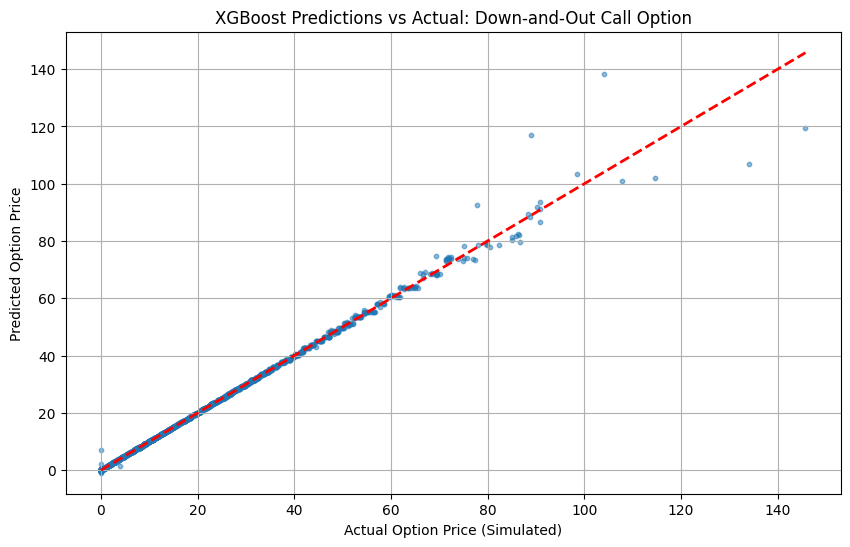

In [7]:
#Visualize predictions and actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Option Price (Simulated)')
plt.ylabel('Predicted Option Price')
plt.title('XGBoost Predictions vs Actual: Down-and-Out Call Option')
plt.grid(True)
plt.show()

In [8]:
import joblib
model_filename = 'daily_stock_classifier_model.pkl'
joblib.dump(pipeline, model_filename)
print(f"Model saved as '{model_filename}'.")

Model saved as 'daily_stock_classifier_model.pkl'.
